In [9]:
from pathlib import Path
import sys
import importlib

# Ensure repo root is on sys.path so local packages (src) import in notebooks
_cwd = Path.cwd().resolve()
_candidates = [_cwd, *_cwd.parents]
_repo_root = next((p for p in _candidates if (p / "src").is_dir()), None)
if _repo_root is None:
    raise RuntimeError("Could not locate repository root containing 'src/'")
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

import numpy as np
import matplotlib.pyplot as plt

# Force reload to avoid stale symbols in long-lived notebook kernels.
import src.physics.reactivity_functions as _rf
_rf = importlib.reload(_rf)

sigmav_DD_BoschHale = _rf.sigmav_DD_BoschHale
sigmav_DT_BoschHale = _rf.sigmav_DT_BoschHale
sigmav_DHe3_BoschHale = _rf.sigmav_DHe3_BoschHale
sigmav_TT_placeholder = _rf.sigmav_TT_placeholder
sigmav_He3He3_placeholder = _rf.sigmav_He3He3_placeholder
sigmav_THe3_placeholder = _rf.sigmav_THe3_placeholder

from src.physics.Tseeded_functions import solve_ode_system

import src.physics.multispecies_functions as _ms
_ms = importlib.reload(_ms)
solve_multispecies_ode_system = _ms.solve_multispecies_ode_system

from src.utils.units_and_constants import species_mass, lambda_T

# -----------------------------------------------------------------------------
# Constants
# -----------------------------------------------------------------------------
ALLOWED_SPECIES = ("D", "T", "He3", "He4")
VALID_INJECTION_MODES = {"auto", "direct", "off"}


In [10]:
def solve_multispecies_manual(
    *,
    V_plasma,
    T_i,
    n_tot,
    species_params,
    TBR_DT,
    TBR_DDn,
    max_simulation_time,
    vector_length,
    targets=None,  # if None, no stopping conditions are applied
    enforce_constant_total_density=True,
    allow_negative_auto_injection=False,
    auto_injection_use_storage_limits=False,
    route_the3_ch3_to_he4=False,
    solver_method="BDF",
    solver_rtol=1e-6,
    solver_atol=1e-3,
):
    # -------------------------------------------------------------------------
    # 1) Validate inputs and map notebook species_params to core solver inputs
    # -------------------------------------------------------------------------
    if targets is None:
        targets = []
    if not isinstance(targets, (list, tuple)):
        raise ValueError("targets must be a list of dictionaries")

    f0 = {}
    species_params_core = {}
    injection_mode = {}
    automatic_injection_weights = {}

    for sp in ALLOWED_SPECIES:
        if sp not in species_params:
            raise ValueError(f"Missing species_params for '{sp}'")
        p = species_params[sp]

        if "f_0" not in p:
            raise ValueError(f"Missing initial fraction 'f_0' for {sp}")

        mode = str(p.get("injection_mode", "off"))
        if mode not in VALID_INJECTION_MODES:
            raise ValueError(f"Invalid injection_mode for {sp}: {mode}")

        f0[sp] = float(p["f_0"])
        injection_mode[sp] = mode
        automatic_injection_weights[sp] = float(p.get("automatic_injection_weight", 1.0))

        species_params_core[sp] = {
            "tau_p": float(p["tau_p"]),
            "lambda_decay": float(p["lambda_decay"]),
            "tau_ifc": float(p.get("tau_ifc", np.inf)),
            "tau_ofc": float(p.get("tau_ofc", np.inf)),
            "N_st_min": float(p.get("N_st_min", 0.0)),
            "Ndot_max": float(p.get("Ndot_max", np.inf)),
            "enable_plasma_channel": bool(p.get("enable_plasma_channel", True)),
        }

    # -------------------------------------------------------------------------
    # 2) Call core ddstartup multispecies solver and return native output structure
    # -------------------------------------------------------------------------
    return solve_multispecies_ode_system(
        V_plasma=float(V_plasma),
        T_i=float(T_i),
        n_tot=float(n_tot),
        f0=f0,
        species_params=species_params_core,
        injection_mode=injection_mode,
        automatic_injection_weights=automatic_injection_weights,
        TBR_DT=float(TBR_DT),
        TBR_DDn=float(TBR_DDn),
        max_simulation_time=float(max_simulation_time),
        vector_length=int(vector_length),
        targets=list(targets),
        enforce_constant_total_density=bool(enforce_constant_total_density),
        allow_negative_auto_injection=bool(allow_negative_auto_injection),
        auto_injection_use_storage_limits=bool(auto_injection_use_storage_limits),
        route_THe3_ch3_to_He4=bool(route_the3_ch3_to_he4),
        solver_method=str(solver_method),
        solver_rtol=float(solver_rtol),
        solver_atol=float(solver_atol),
    )


### Generic reactor parameters

In [11]:
V_plasma = 150.0
T_i = 17.0
n_tot = 1.3e20
max_simulation_time = 10 * 365.25 * 24.0 * 3600.0
vector_length = 1000

# Compute T injection cap exactly as in the original manual T-seeded setup
_, sigmav_DD_n_ref, sigmav_DD_p_ref = sigmav_DD_BoschHale(T_i)
sigmav_DT_ref = sigmav_DT_BoschHale(T_i)

sigmav_TT_ref = float(sigmav_TT_placeholder(T_i))
sigmav_He3He3_ref = float(sigmav_He3He3_placeholder(T_i))
sigmav_THe3_ch1_ref, sigmav_THe3_ch2_ref, sigmav_THe3_ch3_ref = sigmav_THe3_placeholder(T_i)

print("Placeholder extra-channel reactivities at T_i (m^3/s):")
print(f"  TT = {sigmav_TT_ref:.3e}")
print(f"  He3He3 = {sigmav_He3He3_ref:.3e}")
print(f"  THe3 ch1 (He4+p+n, 51%) = {float(sigmav_THe3_ch1_ref):.3e}")
print(f"  THe3 ch2 (He4+D, 43%) = {float(sigmav_THe3_ch2_ref):.3e}")
print(f"  THe3 ch3 (5He+p, 6%) = {float(sigmav_THe3_ch3_ref):.3e}")

tau_p_T = 5.0
Ndot_max_T = (
    n_tot / 2.0 / tau_p_T * V_plasma
    + 0.25 * n_tot**2 * sigmav_DT_ref * V_plasma
    - 0.125 * n_tot**2 * sigmav_DD_p_ref * V_plasma
)


Placeholder extra-channel reactivities at T_i (m^3/s):
  TT = 0.000e+00
  He3He3 = 0.000e+00
  THe3 ch1 (He4+p+n, 51%) = 0.000e+00
  THe3 ch2 (He4+D, 43%) = 0.000e+00
  THe3 ch3 (5He+p, 6%) = 0.000e+00


# reproduce T-seeded startup case (no He3,He4)

DDstartup reproduction check
  original success = True
  multispecies success = True
  original t_startup = 1.133192e+06 s (13.116 d)
  multispecies t_startup = 1.133169e+06 s (13.115 d)
  relative difference = -0.00%
  max |sum(dn/dt)| = 5.960722e+03 m^-3 s^-1
  max |normalized residual| = 1.000000e+00
  max |n_tot drift| = 1.833257e-10


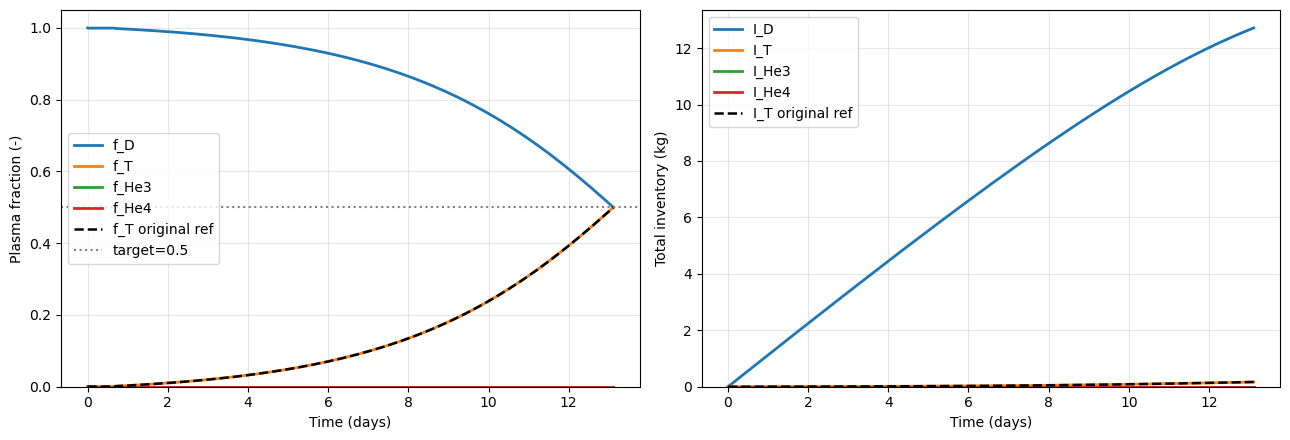

In [12]:
species_params_dd = {
    "D": {
        "f_0": 1.0,
        "tau_p": tau_p_T,
        "lambda_decay": 0.0,
        "tau_ifc": np.inf,
        "tau_ofc": np.inf,
        "N_st_min": 0.0,
        "Ndot_max": np.inf,
        "injection_mode": "auto",
        "automatic_injection_weight": 1.0,
        "enable_plasma_channel": True,
    },
    "T": {
        "f_0": 0.0,
        "tau_p": tau_p_T,
        "lambda_decay": lambda_T,
        "tau_ifc": 4.0 * 3600.0,
        "tau_ofc": 7200.0,
        "N_st_min": 0.001 / species_mass["T"],
        "Ndot_max": Ndot_max_T,
        "injection_mode": "direct",
        "automatic_injection_weight": 0.0,
        "enable_plasma_channel": True,
    },
    "He3": {
        "f_0": 0.0,
        "tau_p": tau_p_T,
        "lambda_decay": 0.0,
        "tau_ifc": np.inf,
        "tau_ofc": np.inf,
        "N_st_min": 0.0,
        "Ndot_max": 0.0,
        "injection_mode": "off",
        "automatic_injection_weight": 0.0,
        "enable_plasma_channel": False,
    },
    "He4": {
        "f_0": 0.0,
        "tau_p": tau_p_T,
        "lambda_decay": 0.0,
        "tau_ifc": np.inf,
        "tau_ofc": np.inf,
        "N_st_min": 0.0,
        "Ndot_max": 0.0,
        "injection_mode": "off",
        "automatic_injection_weight": 0.0,
        "enable_plasma_channel": False,
    },
}

res_dd = solve_multispecies_manual(
    V_plasma=V_plasma,
    T_i=T_i,
    n_tot=n_tot,
    species_params=species_params_dd,
    TBR_DT=1.3,
    TBR_DDn=1.0,
    max_simulation_time=max_simulation_time,
    vector_length=vector_length,
    targets=[{"target_specie": "T", "target_fraction_in_plasma": 0.5}],
    enforce_constant_total_density=True,
    allow_negative_auto_injection=False,
    auto_injection_use_storage_limits=False,
)

# Original ddstartup T-seeded reference solver
orig = solve_ode_system(
    V_plasma=V_plasma,
    n_tot=n_tot,
    tau_p_T=species_params_dd["T"]["tau_p"],
    TBR_DT=1.3,
    TBR_DDn=1.0,
    tau_ifc=species_params_dd["T"]["tau_ifc"],
    tau_ofc=species_params_dd["T"]["tau_ofc"],
    sigmav_DD_p=sigmav_DD_p_ref,
    sigmav_DD_n=sigmav_DD_n_ref,
    sigmav_DT=sigmav_DT_ref,
    injection_rate_max=Ndot_max_T,
    max_simulation_time=max_simulation_time,
    N_st_min=species_params_dd["T"]["N_st_min"],
)

print("DDstartup reproduction check")
print(f"  original success = {orig['sol_success']}")
print(f"  multispecies success = {res_dd['sol_success']}")
print(f"  original t_startup = {orig['t_startup']:.6e} s ({orig['t_startup']/86400.0:.3f} d)")
print(f"  multispecies t_startup = {res_dd['t_startup']:.6e} s ({res_dd['t_startup']/86400.0:.3f} d)")
if np.isfinite(orig["t_startup"]) and np.isfinite(res_dd["t_startup"]):
    rel = (res_dd["t_startup"] - orig["t_startup"]) / orig["t_startup"]
    print(f"  relative difference = {100.0 * rel:.2f}%")

print(f"  max |sum(dn/dt)| = {np.nanmax(np.abs(res_dd['sum_dn_dt'])):.6e} m^-3 s^-1")
print(f"  max |normalized residual| = {np.nanmax(np.abs(res_dd['normalized_residual'])):.6e}")
print(f"  max |n_tot drift| = {np.nanmax(np.abs(res_dd['n_total_rel_drift'])):.6e}")

# Comparison plots: all species fractions and inventories for DDstartup reproduction
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for sp in ALLOWED_SPECIES:
    ax.plot(res_dd["t"] / 86400.0, np.asarray(res_dd[f"n_{sp}"]) / n_tot, lw=2, label=f"f_{sp}")
ax.plot(orig["t"] / 86400.0, orig["n_T"] / n_tot, "k--", lw=1.8, label="f_T original ref")
ax.axhline(0.5, color="gray", linestyle=":", label="target=0.5")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Plasma fraction (-)")
ax.set_ylim(bottom=0.0)
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1]
for sp in ALLOWED_SPECIES:
    inv_kg = (
        np.asarray(res_dd[f"N_ofc_{sp}"])
        + np.asarray(res_dd[f"N_ifc_{sp}"])
        + np.asarray(res_dd[f"N_st_{sp}"])
    ) * species_mass[sp]
    ax.plot(res_dd["t"] / 86400.0, inv_kg, lw=2, label=f"I_{sp}")
I_T_orig = (orig["N_ofc"] + orig["N_ifc"] + orig["N_stor"]) * species_mass["T"]
ax.plot(orig["t"] / 86400.0, I_T_orig, "k--", lw=1.8, label="I_T original ref")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Total inventory (kg)")
ax.set_ylim(bottom=0.0)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# Reproduce T-seeded startup case WITH He3, He4

DDstartup reproduction check
  original success = True
  multispecies success = True
  original t_startup = 1.133192e+06 s (13.116 d)
  multispecies t_startup = 1.159651e+06 s (13.422 d)
  relative difference = 2.33%
  max |sum(dn/dt)| = 8.433062e+03 m^-3 s^-1
  max |normalized residual| = 1.000000e+00
  max |n_tot drift| = 9.891475e-11


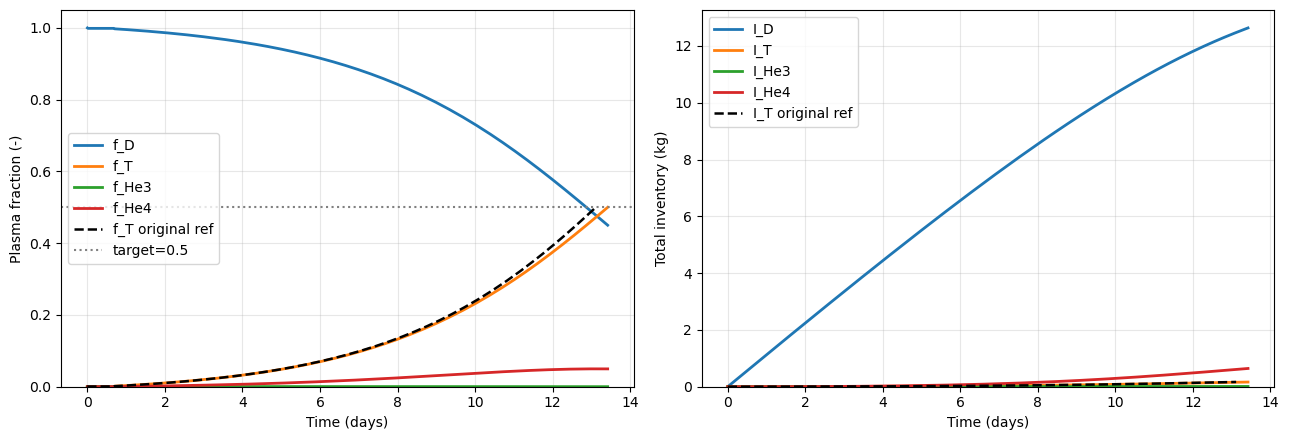

In [13]:
species_params_dd = {
    "D": {
        "f_0": 1.0,
        "tau_p": tau_p_T,
        "lambda_decay": 0.0,
        "tau_ifc": 4.0 * 3600.0,
        "tau_ofc": np.inf,
        "N_st_min": 0.0,
        "Ndot_max": np.inf,
        "injection_mode": "auto",
        "automatic_injection_weight": 1.0,
        "enable_plasma_channel": True,
    },
    "T": {
        "f_0": 0.0,
        "tau_p": tau_p_T,
        "lambda_decay": lambda_T,
        "tau_ifc": 4.0 * 3600.0,
        "tau_ofc": 7200.0,
        "N_st_min": 0.001 / species_mass["T"],
        "Ndot_max": Ndot_max_T,
        "injection_mode": "direct",
        "automatic_injection_weight": 0.0,
        "enable_plasma_channel": True,
    },
    "He3": {
        "f_0": 0.0,
        "tau_p": tau_p_T,
        "lambda_decay": 0.0,
        "tau_ifc": 4.0 * 3600.0,
        "tau_ofc": np.inf,
        "N_st_min": 0.0,
        "Ndot_max": 0.0,
        "injection_mode": "off",
        "automatic_injection_weight": 0.0,
        "enable_plasma_channel": True,
    },
    "He4": {
        "f_0": 0.0,
        "tau_p": tau_p_T,
        "lambda_decay": 0.0,
        "tau_ifc": 4.0 * 3600.0,
        "tau_ofc": np.inf,
        "N_st_min": 0.0,
        "Ndot_max": 0.0,
        "injection_mode": "off",
        "automatic_injection_weight": 0.0,
        "enable_plasma_channel": True,
    },
}

res_dd = solve_multispecies_manual(
    V_plasma=V_plasma,
    T_i=T_i,
    n_tot=n_tot,
    species_params=species_params_dd,
    TBR_DT=1.3,
    TBR_DDn=1.0,
    max_simulation_time=max_simulation_time,
    vector_length=vector_length,
    targets=[{"target_specie": "T", "target_fraction_in_plasma": 0.5}],
    enforce_constant_total_density=True,
    allow_negative_auto_injection=False,
    auto_injection_use_storage_limits=False,
)

# Original ddstartup T-seeded reference solver
orig = solve_ode_system(
    V_plasma=V_plasma,
    n_tot=n_tot,
    tau_p_T=species_params_dd["T"]["tau_p"],
    TBR_DT=1.3,
    TBR_DDn=1.0,
    tau_ifc=species_params_dd["T"]["tau_ifc"],
    tau_ofc=species_params_dd["T"]["tau_ofc"],
    sigmav_DD_p=sigmav_DD_p_ref,
    sigmav_DD_n=sigmav_DD_n_ref,
    sigmav_DT=sigmav_DT_ref,
    injection_rate_max=Ndot_max_T,
    max_simulation_time=max_simulation_time,
    N_st_min=species_params_dd["T"]["N_st_min"],
)

print("DDstartup reproduction check")
print(f"  original success = {orig['sol_success']}")
print(f"  multispecies success = {res_dd['sol_success']}")
print(f"  original t_startup = {orig['t_startup']:.6e} s ({orig['t_startup']/86400.0:.3f} d)")
print(f"  multispecies t_startup = {res_dd['t_startup']:.6e} s ({res_dd['t_startup']/86400.0:.3f} d)")
if np.isfinite(orig["t_startup"]) and np.isfinite(res_dd["t_startup"]):
    rel = (res_dd["t_startup"] - orig["t_startup"]) / orig["t_startup"]
    print(f"  relative difference = {100.0 * rel:.2f}%")

print(f"  max |sum(dn/dt)| = {np.nanmax(np.abs(res_dd['sum_dn_dt'])):.6e} m^-3 s^-1")
print(f"  max |normalized residual| = {np.nanmax(np.abs(res_dd['normalized_residual'])):.6e}")
print(f"  max |n_tot drift| = {np.nanmax(np.abs(res_dd['n_total_rel_drift'])):.6e}")

# Comparison plots: all species fractions and inventories for DDstartup reproduction
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for sp in ALLOWED_SPECIES:
    ax.plot(res_dd["t"] / 86400.0, np.asarray(res_dd[f"n_{sp}"]) / n_tot, lw=2, label=f"f_{sp}")
ax.plot(orig["t"] / 86400.0, orig["n_T"] / n_tot, "k--", lw=1.8, label="f_T original ref")
ax.axhline(0.5, color="gray", linestyle=":", label="target=0.5")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Plasma fraction (-)")
ax.set_ylim(bottom=0.0)
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1]
for sp in ALLOWED_SPECIES:
    inv_kg = (
        np.asarray(res_dd[f"N_ofc_{sp}"])
        + np.asarray(res_dd[f"N_ifc_{sp}"])
        + np.asarray(res_dd[f"N_st_{sp}"])
    ) * species_mass[sp]
    ax.plot(res_dd["t"] / 86400.0, inv_kg, lw=2, label=f"I_{sp}")
I_T_orig = (orig["N_ofc"] + orig["N_ifc"] + orig["N_stor"]) * species_mass["T"]
ax.plot(orig["t"] / 86400.0, I_T_orig, "k--", lw=1.8, label="I_T original ref")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Total inventory (kg)")
ax.set_ylim(bottom=0.0)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# DHe3 with T accumulation in storage

In [14]:
T_DHe3 = 70 # keV

D-He3 case
  success(target reached) = True
  t_startup = inf s (inf d)
  max |sum(dn/dt)| = 7.711331e+03 m^-3 s^-1
  max |normalized residual| = 1.448673e+00
  max |n_tot drift| = 4.518801e-09


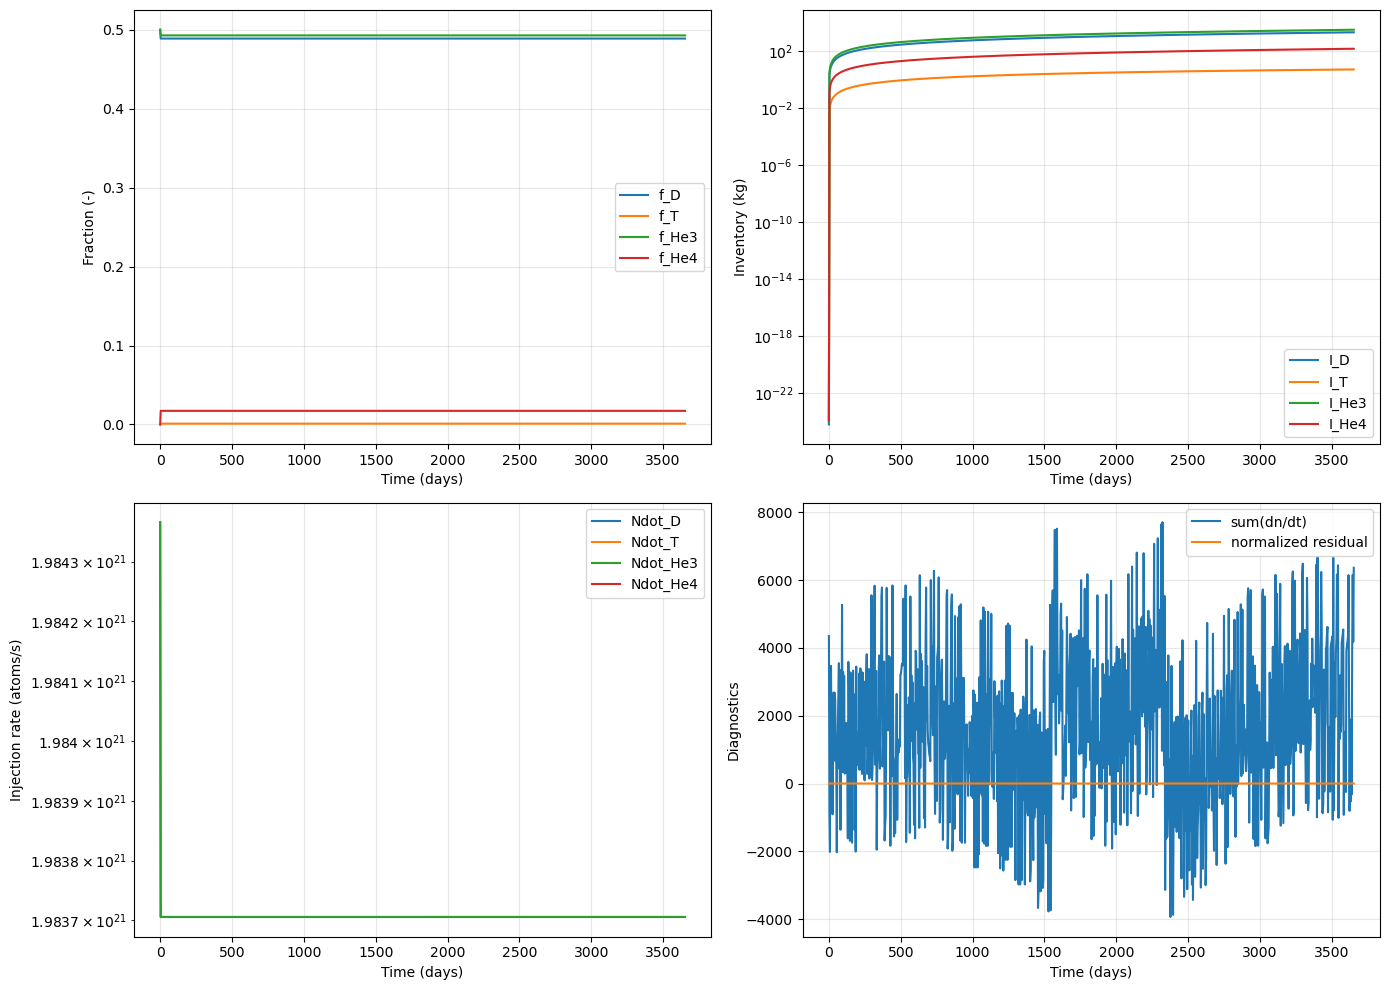

In [15]:
species_params_dhe3 = {
    "D": {
        "f_0": 0.5,
        "tau_p": 5.0,
        "lambda_decay": 0.0,
        "tau_ifc": 4.0 * 3600.0,
        "tau_ofc": np.inf,
        "N_st_min": 0.0,
        "Ndot_max": np.inf,
        "injection_mode": "auto",
        "automatic_injection_weight": 1.0,
        "enable_plasma_channel": True,
    },
    "T": {
        "f_0": 0.0,
        "tau_p": 5.0,
        "lambda_decay": lambda_T,
        "tau_ifc": 4.0 * 3600.0,
        "tau_ofc": 2.0 * 3600.0,
        "N_st_min": 0.001 / species_mass["T"],
        "Ndot_max": np.inf,
        "injection_mode": "off",
        "automatic_injection_weight": 1.0,
        "enable_plasma_channel": True,
    },
    "He3": {
        "f_0": 0.5,
        "tau_p": 5.0,
        "lambda_decay": 0.0,
        "tau_ifc": 4.0 * 3600.0,
        "tau_ofc": np.inf,
        "N_st_min": 0.0,
        "Ndot_max": np.inf,
        "injection_mode": "auto",
        "automatic_injection_weight": 1.0,
        "enable_plasma_channel": True,
    },
    "He4": {
        "f_0": 0.0,
        "tau_p": 5.0,
        "lambda_decay": 0.0,
        "tau_ifc": 4.0 * 3600.0,
        "tau_ofc": np.inf,
        "N_st_min": 0.0,
        "Ndot_max": np.inf,
        "injection_mode": "off",
        "automatic_injection_weight": 1.0,
        "enable_plasma_channel": True,
    },
}

res_dhe3 = solve_multispecies_manual(
    V_plasma=V_plasma,
    T_i=T_DHe3,
    n_tot=n_tot,
    species_params=species_params_dhe3,
    TBR_DT=0.0,
    TBR_DDn=0.0,
    max_simulation_time=max_simulation_time,
    vector_length=vector_length,
    targets=[],
    enforce_constant_total_density=True,
    allow_negative_auto_injection=False,
    auto_injection_use_storage_limits=False,
    route_the3_ch3_to_he4=True,
)

print("D-He3 case")
print(f"  success(target reached) = {res_dhe3['sol_success']}")
print(f"  t_startup = {res_dhe3['t_startup']:.6e} s ({res_dhe3['t_startup']/86400.0:.3f} d)")
print(f"  max |sum(dn/dt)| = {np.nanmax(np.abs(res_dhe3['sum_dn_dt'])):.6e} m^-3 s^-1")
print(f"  max |normalized residual| = {np.nanmax(np.abs(res_dhe3['normalized_residual'])):.6e}")
print(f"  max |n_tot drift| = {np.nanmax(np.abs(res_dhe3['n_total_rel_drift'])):.6e}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
for sp in ALLOWED_SPECIES:
    ax.plot(res_dhe3["t"] / 86400.0, np.asarray(res_dhe3[f"n_{sp}"]) / n_tot, label=f"f_{sp}")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Fraction (-)")
ax.grid(True, alpha=0.3)
ax.set_yscale("linear")
ax.legend()

ax = axes[0, 1]
for sp in ALLOWED_SPECIES:
    inv_kg = (
        np.asarray(res_dhe3[f"N_ofc_{sp}"])
        + np.asarray(res_dhe3[f"N_ifc_{sp}"])
        + np.asarray(res_dhe3[f"N_st_{sp}"])
    ) * species_mass[sp]
    ax.plot(res_dhe3["t"] / 86400.0, inv_kg, label=f"I_{sp}")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Inventory (kg)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1, 0]
for sp in ALLOWED_SPECIES:
    ax.plot(res_dhe3["t"] / 86400.0, np.asarray(res_dhe3[f"Ndot_{sp}"]), label=f"Ndot_{sp}")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Injection rate (atoms/s)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1, 1]
ax.plot(res_dhe3["t"] / 86400.0, res_dhe3["sum_dn_dt"], label="sum(dn/dt)")
ax.plot(res_dhe3["t"] / 86400.0, res_dhe3["normalized_residual"], label="normalized residual")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Diagnostics")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# DHe3 with T reinjection (up to 10% T)

D-He3 case
  success(target reached) = False
  t_startup = inf s (inf d)
  max |sum(dn/dt)| = 6.288983e+03 m^-3 s^-1
  max |normalized residual| = 1.481878e+00
  max |n_tot drift| = 2.090436e-09


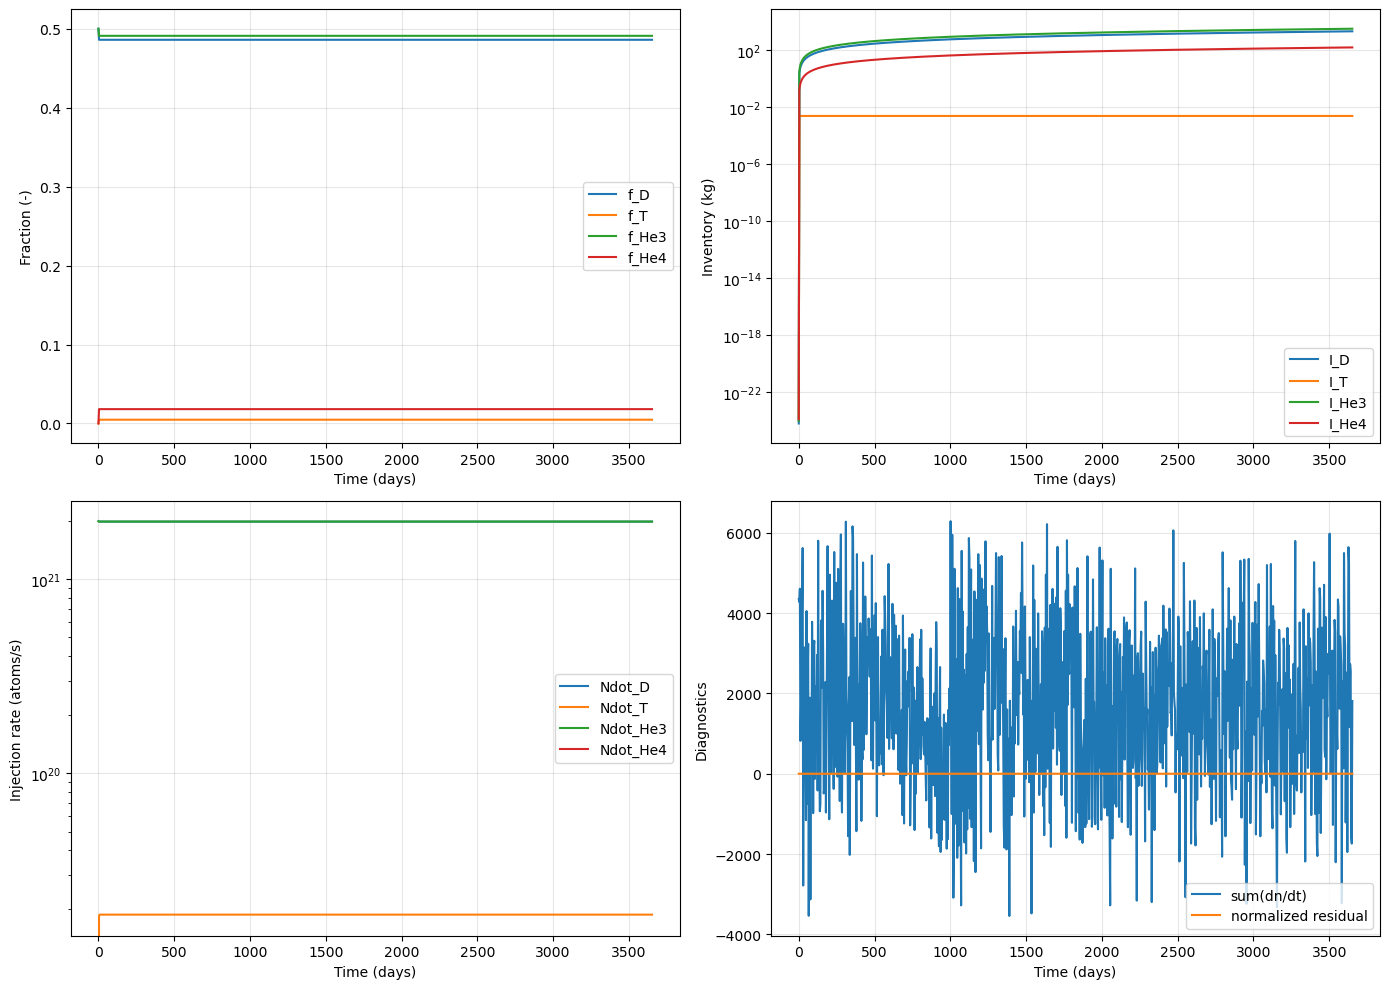

In [19]:
species_params_dhe3 = {
    "D": {
        "f_0": 0.5,
        "tau_p": 5.0,
        "lambda_decay": 0.0,
        "tau_ifc": 4.0 * 3600.0,
        "tau_ofc": np.inf,
        "N_st_min": 0.0,
        "Ndot_max": np.inf,
        "injection_mode": "auto",
        "automatic_injection_weight": 1.0,
        "enable_plasma_channel": True,
    },
    "T": {
        "f_0": 0.0,
        "tau_p": 5.0,
        "lambda_decay": lambda_T,
        "tau_ifc": 4.0 * 3600.0,
        "tau_ofc": 2.0 * 3600.0,
        "N_st_min": 0.001 / species_mass["T"],
        "Ndot_max": np.inf,
        "injection_mode": "direct",
        "automatic_injection_weight": 1.0,
        "enable_plasma_channel": True,
    },
    "He3": {
        "f_0": 0.5,
        "tau_p": 5.0,
        "lambda_decay": 0.0,
        "tau_ifc": 4.0 * 3600.0,
        "tau_ofc": np.inf,
        "N_st_min": 0.0,
        "Ndot_max": np.inf,
        "injection_mode": "auto",
        "automatic_injection_weight": 1.0,
        "enable_plasma_channel": True,
    },
    "He4": {
        "f_0": 0.0,
        "tau_p": 5.0,
        "lambda_decay": 0.0,
        "tau_ifc": 4.0 * 3600.0,
        "tau_ofc": np.inf,
        "N_st_min": 0.0,
        "Ndot_max": np.inf,
        "injection_mode": "off",
        "automatic_injection_weight": 1.0,
        "enable_plasma_channel": True,
    },
}

res_dhe3 = solve_multispecies_manual(
    V_plasma=V_plasma,
    T_i=T_DHe3,
    n_tot=n_tot,
    species_params=species_params_dhe3,
    TBR_DT=0.0,
    TBR_DDn=0.0,
    max_simulation_time=max_simulation_time,
    vector_length=vector_length,
    targets=[{"target_specie": "T", "target_fraction_in_plasma": 0.10}],
    enforce_constant_total_density=True,
    allow_negative_auto_injection=False,
    auto_injection_use_storage_limits=False,
    route_the3_ch3_to_he4=True,
)

print("D-He3 case")
print(f"  success(target reached) = {res_dhe3['sol_success']}")
print(f"  t_startup = {res_dhe3['t_startup']:.6e} s ({res_dhe3['t_startup']/86400.0:.3f} d)")
print(f"  max |sum(dn/dt)| = {np.nanmax(np.abs(res_dhe3['sum_dn_dt'])):.6e} m^-3 s^-1")
print(f"  max |normalized residual| = {np.nanmax(np.abs(res_dhe3['normalized_residual'])):.6e}")
print(f"  max |n_tot drift| = {np.nanmax(np.abs(res_dhe3['n_total_rel_drift'])):.6e}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
for sp in ALLOWED_SPECIES:
    ax.plot(res_dhe3["t"] / 86400.0, np.asarray(res_dhe3[f"n_{sp}"]) / n_tot, label=f"f_{sp}")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Fraction (-)")
ax.grid(True, alpha=0.3)
ax.set_yscale("linear")
ax.legend()

ax = axes[0, 1]
for sp in ALLOWED_SPECIES:
    inv_kg = (
        np.asarray(res_dhe3[f"N_ofc_{sp}"])
        + np.asarray(res_dhe3[f"N_ifc_{sp}"])
        + np.asarray(res_dhe3[f"N_st_{sp}"])
    ) * species_mass[sp]
    ax.plot(res_dhe3["t"] / 86400.0, inv_kg, label=f"I_{sp}")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Inventory (kg)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1, 0]
for sp in ALLOWED_SPECIES:
    ax.plot(res_dhe3["t"] / 86400.0, np.asarray(res_dhe3[f"Ndot_{sp}"]), label=f"Ndot_{sp}")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Injection rate (atoms/s)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1, 1]
ax.plot(res_dhe3["t"] / 86400.0, res_dhe3["sum_dn_dt"], label="sum(dn/dt)")
ax.plot(res_dhe3["t"] / 86400.0, res_dhe3["normalized_residual"], label="normalized residual")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Diagnostics")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()
